# Truncating walkers without charge blocks

`fixed_block_walkers.ipynb` found that most of production's walker truncation error comes from the **kept counts per charge sector that `plan_bonds` freezes on the reference**. Each walker's own counts on the same circuit sit within 2–4× of the optimum. Production can't use per-walker counts directly: the counts are baked into the jitted program, and every walker in a vmapped batch must share one program. Padding every sector to the largest count any walker uses keeps the shapes static, but then everything downstream pays for the padded bond.

**The idea tested here.** With the orthogonality centre on the gate, the two-site matrix is block-diagonal in charge. A plain dense SVD of it, keeping its $\chi$ largest singular values, therefore keeps exactly the walker's own counts. There are no charge blocks, the bond is at most $\chi$, and every shape is fixed by $\chi$ alone, so it compiles once and vmaps. What it gives up is the static bond charge labels. Production uses them in three places:

1. to split into sector blocks, which is only a speed-up;
2. in the blocked overlap and fast-sweep contractions with the DMRG trial;
3. for the fermionic reordering sign $(-1)^{n_{\uparrow i}N_\downarrow(<i)}$ when the two spin channels meet the spin-entangled trial.

Here (2) becomes a dense contraction, and (3) is carried as a parity index in the contraction's environment.

**What is checked**, on the $L=8$ and $12$ walker sets of `entanglement_vs_gmps.ipynb` (UHF and DMRG trials, $U=4$ and $6$), all against exact dense states:

| test | compares | expected |
|---|---|---|
| D1 | dense-truncation gMPS against own counts (`channel_mps_own`, and `plan_bonds` run on the walker) | the same state to roundoff |
| D2 | weight of the dense-truncation gMPS outside the walker's particle number | zero, unless a tie at the truncation edge lets the SVD mix sectors |
| D3 | parity-carrying DMRG overlap against the charge-labelled one and against the exact $a_\uparrow^{\mathsf T}M_Ta_\downarrow$ | agreement to roundoff (labelled) or to the fixed-block error (exact) |
| D4 | accuracy: exact infidelity per spin channel and $\delta O$ per walker, production against dense truncation, with the optimum | dense truncation at the own-counts level |
| D5 | cost: jitted, vmapped conversion plus DMRG-trial overlap, production against dense truncation, at $L=12$ and $32$ | an open question |

The fast sweep (`make_fast_sweep`), which is most of production's time per step, is not ported. D5 times only the conversion and one overlap.

| symbol | meaning |
|---|---|
| $L$, $N$ | sites, electrons per spin (half filling) |
| $Q$ | a walker spin channel's orthonormalised $L\times N$ orbitals |
| $\chi$ | walker bond per spin channel (production's `walker_channel_chi`) |
| production | `channel_mps(Q, plan, plan_bonds(ref, plan, χ))`: kept counts frozen on the plan reference |
| own counts | the same circuit with each walker's own kept counts: `channel_mps_own`, or `plan_bonds(Q, plan, χ)` |
| dense truncation | `channel_mps_dense(Q, plan, χ)` below |
| $a(\chi)$ | the optimum $\max_b\big(1-\sum_{i\le\chi}\lambda^{(b)}_i\big)$ from the dense Schmidt values, which no bond-$\chi$ MPS can beat |
| $\delta O$ | $\lvert O_{\rm gMPS}/O-1\rvert$ per walker (both spins), against the exact overlap with the trial |

In [1]:
from pathlib import Path

# ---- walker sets of entanglement_vs_gmps.ipynb (read only): Hubbard, open chain, t = 1, half filling
SETS = {f"L{L}_U{U}_{trial}": dict(L=L, U=float(U), trial=trial)
        for L in (8, 12) for U in (4, 6) for trial in ("uhf", "dmrg")}
SRC_DIR = Path("entanglement_vs_gmps_data")
TRIAL_CHI, DMRG_SWEEPS = 8, 14      # the DMRG trial those walkers were guided by
# ---- analysis
EPS = 1.0e-10                       # purity tolerance of the plans (mps_cpmc_new default)
CHIS = (2, 4, 8, 12, 16)            # walker bond per spin channel
SNAPSHOTS = 6                       # evenly spaced sampling-phase snapshots per set, 50 walkers each
# ---- cost (D5): the L=32 DMRG trial and walkers of fixed_block_walkers.ipynb
L32_TRIAL = Path("fw_block_data/dmrg_trial_L32_U4_chi8.npz")
L32_WALKERS = Path("fw_block_data/L32_U4_nw200_s1234_walkers.npz")
TIMING_CHIS = {12: CHIS, 32: (4, 8, 12, 16)}   # per system size
TIMING_REPS = 20
# ---- cached in dense_truncation_data/; recomputed if missing or RERUN
DATA_DIR = Path("dense_truncation_data")
RERUN = False

In [2]:
import json
import sys
import time
from functools import lru_cache
from itertools import combinations
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

sys.path.insert(0, str(Path.cwd()))           # this folder: mps_cpmc_new.py
import mps_cpmc_new as mcn
from mps_cpmc_new import (make_orbital_plan, channel_angles, channel_mps, plan_bonds, hopping_matrix,
                          gate_pair, sector_plan, _move_centre, _assemble)

PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#8e5bd0", "#d4a20f", "#d6457a", "#3b9ab2", "#7a5230"]
INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e6e5e1", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.linewidth": 1.0, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 14, "axes.labelsize": 10, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 1.0, "grid.linestyle": "-",
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2.0,
    "lines.solid_capstyle": "round", "legend.frameon": False, "font.size": 10,
})
LEGEND = dict(loc="upper left", bbox_to_anchor=(1.01, 1.0))
COLOR = {name: PALETTE[i % len(PALETTE)] for i, name in enumerate(SETS)}
LABEL = {name: f"L={s['L']}, U={s['U']:g}, {s['trial'].upper()} trial" for name, s in SETS.items()}
DATA_DIR.mkdir(exist_ok=True)


def save(fig, name):
    path = DATA_DIR / f"{name}.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"saved {path}")


def cached(path, compute):
    # np.load of the file at path, computing and saving it first if missing or RERUN
    if RERUN or not path.exists():
        start = time.perf_counter()
        np.savez_compressed(path, **compute())
        print(f"computed {path.name} in {time.perf_counter() - start:.0f} s")
    return dict(np.load(path))

## Tools

- **`channel_mps_dense(Q, plan, χ)`.** Production's gate circuit from `channel_angles`, with dense centre moves (QR and LQ). At every gate it keeps the $\chi$ leading eigenvectors of the two-site matrix's Gram matrix $MM^{\mathsf T}$: production's own truncated factorisation (`_factor_block`), applied to the whole matrix instead of per sector. Bonds are $\min(\chi, 2D_l, 2D_r)$, fixed by the circuit and $\chi$ alone, and the gauge is `channel_mps`'s $\det R[\mathrm{occ},:]$. A dense SVD instead gives the same states to $10^{-15}$ but is 1.7× slower at $L=32$.
- **`dmrg_overlap_parity(α, β, trial)`.** $\langle\Psi_T|\alpha\otimes\beta\rangle$ contracted site by site with an environment $E[p,a,b,t]$. Here $p=N_\downarrow(<i)\bmod 2$ is the parity of the down electrons already passed. A down electron flips $p$ for the sites after it, and an up electron at site $i$ takes the sign $(-1)^p$. That is `combine_channels`' reordering sign, read from the physical indices instead of the bond labels, so it works for any number-conserving $\beta$.
- **For the checks:** `channel_mps_own` (from `fixed_block_walkers.ipynb`: untruncated shapes, all but the $\chi$ largest Schmidt values zeroed), and the charge-labelled overlap `dmrg_overlap_labels`.
- **Exact references,** as in `entanglement_vs_gmps.ipynb`: the walker's amplitudes $\det Q[I,:]$ over all occupation strings $I$ (site 0 most significant), the DMRG trial as the sector matrix $M_T[I,J]=\langle I_\uparrow J_\downarrow|\Psi_T\rangle$ (`sector_matrix`, validated there against production's overlap to $6\times10^{-15}$), and every gMPS contracted to its full $2^L$ vector.

In [3]:
def _shift_dense(tensors, site, step):
    # move the orthogonality centre from site to site + step (+1 or -1) by a dense QR or LQ
    A = tensors[site]
    Dl, _, Dr = A.shape
    if step > 0:
        q, r = jnp.linalg.qr(A.reshape(2 * Dl, Dr))
        tensors[site] = q.reshape(Dl, 2, -1)
        tensors[site + 1] = jnp.tensordot(r, tensors[site + 1], axes=1)
    else:
        q, r = jnp.linalg.qr(A.reshape(Dl, 2 * Dr).T)
        tensors[site] = q.T.reshape(-1, 2, Dr)
        tensors[site - 1] = jnp.tensordot(tensors[site - 1], r.T, axes=1)


def channel_mps_dense(C, plan, chi):
    # production's circuit, but every split is dense: the chi leading eigenvectors of the two-site matrix's Gram matrix
    # M M^T (production's own truncated factorisation, without charge sectors), bonds min(chi, 2 D_l, 2 D_r). With the
    # centre on the gate, M is block-diagonal in charge, so the kept values are the walker's own counts.
    # Returns (tensors, gauge).
    tensors = [jnp.eye(2)[int(o)].reshape(1, 2, 1) for o in plan.occupation]
    angles, rows = channel_angles(C, plan)
    centre = None
    for site, theta in reversed(angles):
        if centre is not None:                 # None: the initial product state, already canonical everywhere
            while centre > site:
                _shift_dense(tensors, centre, -1)
                centre -= 1
            while centre < site:
                _shift_dense(tensors, centre, +1)
                centre += 1
        pair = gate_pair(tensors[site], tensors[site + 1], theta)
        Dl, _, _, Dr = pair.shape
        M = pair.reshape(2 * Dl, 2 * Dr)
        k = min(chi, 2 * Dl, 2 * Dr)
        _, U = jnp.linalg.eigh(M @ M.T)
        Uk = U[:, ::-1][:, :k]
        tensors[site], tensors[site + 1] = Uk.reshape(Dl, 2, k), (Uk.T @ M).reshape(k, 2, Dr)
        centre = site + 1
    gauge = jnp.linalg.det(jnp.stack([rows[i] for i in np.flatnonzero(plan.occupation)]))
    return tensors, gauge


def channel_mps_own(C, plan, chi):
    # fixed_block_walkers.ipynb: production's charge-blocked circuit on untruncated shapes, every split zeroing all
    # but the chi largest Schmidt values over its sectors (the state of channel_mps(C, plan, plan_bonds(C, plan, chi)))
    tensors = [jnp.eye(2)[int(o)].reshape(1, 2, 1) for o in plan.occupation]
    charges = [np.zeros(1, int)]
    for o in plan.occupation:
        charges.append(charges[-1] + int(o))
    angles, _ = channel_angles(C, plan)
    centre = None
    for site, theta in reversed(angles):
        centre = _move_centre(tensors, charges, centre, site)
        pair = gate_pair(tensors[site], tensors[site + 1], theta)
        Dl, _, _, Dr = pair.shape
        M = pair.reshape(2 * Dl, 2 * Dr)
        sp = sector_plan(charges[site], charges[site + 2])
        svds = [jnp.linalg.svd(M[np.ix_(r, c)], full_matrices=False) for r, c, _ in sp.sectors]
        s_all = jnp.concatenate([s for _, s, _ in svds])
        keep = jnp.zeros(s_all.shape).at[jnp.argsort(-s_all)[:chi]].set(1.0)
        left, right, offset = [], [], 0
        for u, s, vh in svds:
            k = keep[offset:offset + s.shape[0]]
            offset += s.shape[0]
            left.append(u * k)
            right.append((s * k)[:, None] * vh)
        A, B = _assemble(left, right, sp)
        tensors[site], tensors[site + 1] = A.reshape(Dl, 2, -1), B.reshape(-1, 2, Dr)
        charges[site + 1] = sp.middle_charges
        centre = site + 1
    return tensors


def dmrg_overlap_parity(alpha, beta, trial):
    # <Psi_T | alpha x beta> with an environment E[p, a, b, t], p = parity of the down electrons already passed: a
    # down electron flips p for later sites, an up electron takes (-1)^p (combine_channels' reordering sign)
    E = jnp.zeros((2, 1, 1, 1)).at[0].set(1.0)
    flip = jnp.array([1.0, -1.0])[:, None, None, None]
    for A, B, T in zip(alpha, beta, trial):
        new = 0.0
        for na in (0, 1):
            for nb in (0, 1):
                X = jnp.einsum("pabt,ar,bs,tu->prsu", E, A[:, na, :], B[:, nb, :], T[:, na + 2 * nb, :], optimize=True)
                X = X * flip if na else X
                new = new + (X[::-1] if nb else X)
        E = new
    return E[:, 0, 0, 0].sum()


def dmrg_overlap_labels(alpha, beta, qb, trial):
    # the same overlap with the sign read from beta's bond charge labels (fixed_block_walkers.ipynb)
    E = jnp.ones((1, 1, 1))
    for A, B, q, T in zip(alpha, beta, qb, trial):
        sign = jnp.asarray((-1.0) ** np.asarray(q))
        E = sum(jnp.einsum("abt,ar,b,bs,tu->rsu", E, A[:, na, :], sign if na else jnp.ones_like(sign), B[:, nb, :],
                           T[:, na + 2 * nb, :], optimize=True) for na in (0, 1) for nb in (0, 1))
    return E[0, 0, 0]


def jdot(A, B):
    E = jnp.ones((1, 1))
    for a, b in zip(A, B):
        E = jnp.einsum("ab,apc,bpd->cd", E, a, b)
    return E[0, 0]


def mps_vector(tensors):
    # all 2^L amplitudes of a d=2 MPS, site 0 most significant (dense_state's order)
    v = tensors[0][0]
    for t in tensors[1:]:
        v = (v @ t.reshape(t.shape[0], -1)).reshape(-1, t.shape[2])
    return v.reshape(-1)


# ---- exact references (entanglement_vs_gmps.ipynb)
def orthonormal(W):
    return np.linalg.qr(W)[0]


@lru_cache(maxsize=None)
def _basis(L, N):
    combos = np.array(list(combinations(range(L), N)))
    return combos, (1 << (L - 1 - combos)).sum(axis=1)


def dense4(tensors):
    # amplitudes of a d=4 MPS over all 4^L local states (site 0 most significant)
    L, h = len(tensors), len(tensors) // 2
    left = np.asarray(tensors[0])[0]
    for t in tensors[1:h]:
        left = np.tensordot(left, np.asarray(t), axes=([-1], [0])).reshape(-1, np.asarray(t).shape[-1])
    right = np.asarray(tensors[-1])[:, :, 0]
    for t in reversed(tensors[h:-1]):
        right = np.tensordot(np.asarray(t), right, axes=([-1], [0])).reshape(np.asarray(t).shape[0], -1)
    return (left @ right).reshape(-1)


def sector_matrix(vec4, L, N):
    # <I_up J_dn|state> in the up-then-down string order of the determinant amplitudes
    combos, _ = _basis(L, N)
    occ = np.zeros((len(combos), L), int)
    occ[np.arange(len(combos))[:, None], combos] = 1
    local = occ[:, None, :] + 2 * occ[None, :, :]
    dn_left = np.concatenate([np.zeros((len(combos), 1), int), np.cumsum(occ, axis=1)[:, :-1]], axis=1)
    sign = (-1.0) ** (occ[:, None, :] * dn_left[None, :, :]).sum(-1)
    return vec4[local @ (4 ** np.arange(L - 1, -1, -1))] * sign


def uhf_scf(h1, u, na, nb, guess=0.3, mix=0.5, tol=1e-12, iters=5000):
    # fixed_block_walkers.ipynb's SCF, unchanged
    n = h1.shape[0]
    stag = (-1.0) ** np.arange(n)
    da, db = na / n + guess * stag, nb / n - guess * stag
    for it in range(iters):
        _, va = np.linalg.eigh(h1 + u * np.diag(db))
        _, vb = np.linalg.eigh(h1 + u * np.diag(da))
        Ca, Cb = va[:, :na], vb[:, :nb]
        new_a, new_b = np.einsum("ik,ik->i", Ca, Ca), np.einsum("ik,ik->i", Cb, Cb)
        change = max(abs(new_a - da).max(), abs(new_b - db).max())
        da, db = (1 - mix) * da + mix * new_a, (1 - mix) * db + mix * new_b
        if change < tol:
            break
    return Ca, Cb

## Walker sets, trials and plans

The walkers are `entanglement_vs_gmps.ipynb`'s: trot CPMC, 50 walkers, 10 + 30 blocks, seed 1234. `SNAPSHOTS` evenly spaced sampling-phase snapshots are used per set, and every walker is QR-orthonormalised first. The plans are production's: `make_orbital_plan(ref, "adaptive", ε)` and `plan_bonds(ref, plan, χ)` on the plan reference. That reference is the UHF determinant for the UHF trial, and the natural-orbital determinant for the DMRG trial.

The DMRG trial's MPS tensors aren't in the cached files, which hold only its sector matrix. They are rebuilt here with the same `run_dmrg` settings, and the rebuilt $M_T$ is checked against the cached one.

In [4]:
WALK, TRIAL, REF, PLAN = {}, {}, {}, {}
for name, s in SETS.items():
    L, N, U = s["L"], s["L"] // 2, s["U"]
    z = np.load(SRC_DIR / f"{name}_nw50_b10+30_s1234_walkers.npz")
    cfg = json.loads(str(z["config"]))
    samp = np.flatnonzero(np.arange(z["up"].shape[0]) > cfg["N_EQL"])
    sel = samp[np.unique(np.linspace(0, len(samp) - 1, SNAPSHOTS).round().astype(int))]
    WALK[name] = tuple(np.stack([orthonormal(W) for W in z[k][sel].reshape(-1, L, N)]) for k in ("up", "dn"))
    if s["trial"] == "uhf":
        TRIAL[name] = dict(kind="uhf", C=uhf_scf(hopping_matrix(L, 1.0), U, N, N))
        REF[name] = TRIAL[name]["C"]                     # a determinant's natural orbitals are its own orbitals
        info = ""
    else:
        def build(L=L, N=N, U=U):
            c = mcn.Config(L=L, n_up=N, n_down=N, interaction=U, trial_chi=TRIAL_CHI, dmrg_sweeps=DMRG_SWEEPS)
            tensors, charges = mcn.densify_with_charges(mcn.run_dmrg(mcn.build_dmrg_hamiltonian(c), c)[0], L)
            return {**{f"T{i}": A for i, A in enumerate(tensors)}, **{f"q{i}": q for i, q in enumerate(charges)}}
        t = cached(DATA_DIR / f"dmrg_trial_L{L}_U{U:g}_chi{TRIAL_CHI}_tensors.npz", build)
        T = [t[f"T{i}"] for i in range(L)]
        M_T = sector_matrix(dense4(T), L, N)
        old = np.load(SRC_DIR / f"dmrg_trial_L{L}_U{U:g}_chi{TRIAL_CHI}.npz")
        unit = M_T / np.linalg.norm(M_T)
        info = f"   rebuilt trial vs cached M_T: max |diff| {min(np.abs(unit - old['M_T']).max(), np.abs(unit + old['M_T']).max()):.1e}"
        TRIAL[name] = dict(kind="dmrg", T=[jnp.asarray(A) for A in T], M_T=M_T)
        REF[name] = tuple(mcn.natural_orbitals(g, N)[0] for g in old["gamma"])   # plan_reference="natural"
    PLAN[name] = [make_orbital_plan(C, "adaptive", EPS) for C in REF[name]]
    print(f"{name:12s}: {WALK[name][0].shape[0]} walkers, plan B_k (↑) {PLAN[name][0].block_sizes.tolist()}{info}")

L8_U4_uhf   : 300 walkers, plan B_k (↑) [5, 4, 4, 3, 3, 2, 2]
QC MPO site   0 / 8
QC MPO site   1 / 8
QC MPO site   2 / 8
QC MPO site   3 / 8
QC MPO site   4 / 8
QC MPO site   5 / 8
QC MPO site   6 / 8
QC MPO site   7 / 8


computed dmrg_trial_L8_U4_chi8_tensors.npz in 0 s
L8_U4_dmrg  : 300 walkers, plan B_k (↑) [5, 4, 4, 3, 3, 2, 2]   rebuilt trial vs cached M_T: max |diff| 0.0e+00
L8_U6_uhf   : 300 walkers, plan B_k (↑) [4, 4, 4, 3, 3, 2, 2]
QC MPO site   0 / 8
QC MPO site   1 / 8
QC MPO site   2 / 8
QC MPO site   3 / 8
QC MPO site   4 / 8
QC MPO site   5 / 8
QC MPO site   6 / 8
QC MPO site   7 / 8


computed dmrg_trial_L8_U6_chi8_tensors.npz in 0 s
L8_U6_dmrg  : 300 walkers, plan B_k (↑) [5, 4, 4, 3, 3, 2, 2]   rebuilt trial vs cached M_T: max |diff| 5.6e-17
L12_U4_uhf  : 300 walkers, plan B_k (↑) [5, 5, 5, 5, 5, 4, 4, 3, 3, 2, 2]
QC MPO site   0 / 12
QC MPO site   1 / 12
QC MPO site   2 / 12
QC MPO site   3 / 12
QC MPO site   4 / 12
QC MPO site   5 / 12
QC MPO site   6 / 12
QC MPO site   7 / 12
QC MPO site   8 / 12
QC MPO site   9 / 12
QC MPO site  10 / 12
QC MPO site  11 / 12


computed dmrg_trial_L12_U4_chi8_tensors.npz in 1 s
L12_U4_dmrg : 300 walkers, plan B_k (↑) [6, 6, 6, 5, 5, 4, 4, 3, 3, 2, 2]   rebuilt trial vs cached M_T: max |diff| 3.1e-16
L12_U6_uhf  : 300 walkers, plan B_k (↑) [4, 4, 4, 4, 4, 4, 4, 3, 3, 2, 2]
QC MPO site   0 / 12
QC MPO site   1 / 12
QC MPO site   2 / 12
QC MPO site   3 / 12
QC MPO site   4 / 12
QC MPO site   5 / 12
QC MPO site   6 / 12
QC MPO site   7 / 12
QC MPO site   8 / 12
QC MPO site   9 / 12
QC MPO site  10 / 12
QC MPO site  11 / 12


computed dmrg_trial_L12_U6_chi8_tensors.npz in 1 s
L12_U6_dmrg : 300 walkers, plan B_k (↑) [7, 6, 6, 5, 5, 4, 4, 3, 3, 2, 2]   rebuilt trial vs cached M_T: max |diff| 5.6e-17


## Evaluating every conversion on every walker

For each set and $\chi$, one jitted, vmapped function converts both spin channels of every walker four ways:

- **full**: the untruncated fixed plan;
- **production**;
- **own counts**;
- **dense truncation**.

It contracts each gMPS to its $2^L$ vector and returns:

- the exact infidelity $1-F$ of each channel against the walker's amplitudes $\det Q[I,:]$;
- the weight outside the walker's particle number;
- the fidelity and norm difference between dense truncation and own counts;
- each conversion's overlap with the trial, next to the exact one.

For the DMRG trial, the production overlap is also computed with the charge-labelled sign, as a check of the parity-carrying one.

The optimum $a(\chi)$ comes from the dense Schmidt values of each channel (an SVD of the exact vector at every cut).

In [5]:
def make_eval(name, chi):
    s, plans, tr = SETS[name], PLAN[name], TRIAL[name]
    L, N = s["L"], s["L"] // 2
    combos, index = (jnp.asarray(x) for x in _basis(L, N))
    bonds = [plan_bonds(C, p, chi, 0.0) for C, p in zip(REF[name], plans)]
    if tr["kind"] == "uhf":
        tgmps = [channel_mps(jnp.asarray(C), p)[::2] for C, p in zip(tr["C"], plans)]
        C_T = [jnp.asarray(C) for C in tr["C"]]
    else:
        M_T = jnp.asarray(tr["M_T"])

    def overlap(A, g):
        # <Psi_T | walker> of the gMPS pair A = (alpha, beta) with gauges g
        if tr["kind"] == "uhf":
            return g[0] * g[1] * jnp.prod(jnp.stack([gT * jdot(tT, a) for (tT, gT), a in zip(tgmps, A)]))
        return g[0] * g[1] * dmrg_overlap_parity(A[0], A[1], tr["T"])

    def one(qa, qb):
        Q = (qa, qb)
        amp = [jnp.linalg.det(q[combos]) for q in Q]                      # exact amplitudes, norm 1
        if tr["kind"] == "uhf":
            O = jnp.linalg.det(C_T[0].T @ qa) * jnp.linalg.det(C_T[1].T @ qb)
        else:
            O = amp[0] @ M_T @ amp[1]
        full = [channel_mps(q, p) for q, p in zip(Q, plans)]
        g = [f[2] for f in full]
        prod = [channel_mps(q, p, b) for q, p, b in zip(Q, plans, bonds)]
        conv = dict(full=[f[0] for f in full], prod=[p_[0] for p_ in prod],
                    own=[channel_mps_own(q, p, chi) for q, p in zip(Q, plans)],
                    dense=[channel_mps_dense(q, p, chi)[0] for q, p in zip(Q, plans)])
        out = {}
        for key, A in conv.items():
            vecs = [mps_vector(a) for a in A]
            norm = [v @ v for v in vecs]
            out[f"F_{key}"] = jnp.stack([(x @ v[index]) ** 2 / n for x, v, n in zip(amp, vecs, norm)])
            out[f"leak_{key}"] = jnp.stack([1 - (v[index] @ v[index]) / n for v, n in zip(vecs, norm)])
            out[f"dO_{key}"] = jnp.abs(overlap(A, g) / O - 1)
            if key in ("dense", "own"):
                out[f"vec_{key}"] = vecs
        vd, vo = out.pop("vec_dense"), out.pop("vec_own")
        out["F_dense_own"] = jnp.stack([(a @ b) ** 2 / ((a @ a) * (b @ b)) for a, b in zip(vd, vo)])
        out["dnorm_dense_own"] = jnp.stack([jnp.abs(a @ a - b @ b) for a, b in zip(vd, vo)])
        if tr["kind"] == "dmrg":
            A, qdn = conv["prod"], prod[1][1]
            out["labels_vs_parity"] = jnp.abs(dmrg_overlap_labels(A[0], A[1], qdn, tr["T"])
                                              / dmrg_overlap_parity(A[0], A[1], tr["T"]) - 1)
        return out
    return jax.jit(jax.vmap(one))


def optimum(name):
    # a(chi) = max_b (1 - sum of the chi largest Schmidt values at cut b), per walker channel, from the dense state
    L, N = SETS[name]["L"], SETS[name]["L"] // 2
    combos, index = _basis(L, N)
    out = np.zeros(WALK[name][0].shape[:1] + (2, len(CHIS)))
    for s_, W in enumerate(WALK[name]):
        for w, Q in enumerate(W):
            psi = np.zeros(2 ** L)
            psi[index] = np.linalg.det(Q[combos])
            for b in range(1, L):
                cum = np.cumsum(np.linalg.svd(psi.reshape(2 ** b, -1), compute_uv=False) ** 2)
                out[w, s_] = np.maximum(out[w, s_], [1 - cum[min(c, len(cum)) - 1] for c in CHIS])
    return dict(a=out)


R = {}
for name in SETS:
    R[name] = {}
    for chi in CHIS:
        def compute(name=name, chi=chi):
            res = make_eval(name, chi)(jnp.asarray(WALK[name][0]), jnp.asarray(WALK[name][1]))
            return {k: np.asarray(v) for k, v in res.items()}
        R[name][chi] = cached(DATA_DIR / f"{name}_eps{EPS:.0e}_n{SNAPSHOTS}_chi{chi}.npz", compute)
    R[name]["a"] = cached(DATA_DIR / f"{name}_n{SNAPSHOTS}_optimum.npz", lambda name=name: optimum(name))["a"]

computed L8_U4_uhf_eps1e-10_n6_chi2.npz in 9 s


computed L8_U4_uhf_eps1e-10_n6_chi4.npz in 4 s


computed L8_U4_uhf_eps1e-10_n6_chi8.npz in 5 s


computed L8_U4_uhf_eps1e-10_n6_chi12.npz in 4 s


computed L8_U4_uhf_eps1e-10_n6_chi16.npz in 4 s
computed L8_U4_uhf_n6_optimum.npz in 0 s


...

computed L12_U6_dmrg_eps1e-10_n6_chi4.npz in 14 s


computed L12_U6_dmrg_eps1e-10_n6_chi8.npz in 15 s


computed L12_U6_dmrg_eps1e-10_n6_chi12.npz in 15 s


computed L12_U6_dmrg_eps1e-10_n6_chi16.npz in 15 s


computed L12_U6_dmrg_n6_optimum.npz in 1 s


## D1–D3: is dense truncation the own counts, and is the overlap right?

Per set and $\chi$, the worst case over all walkers (both spins):

- **D1**: $1-F$ between the dense-truncation and own-counts states, and the difference of their norms. The norm is the weight each truncation kept, so it must agree too.
- **D2**: the weight of the dense-truncation state outside the walker's particle number, and the same for production as a reference (exactly zero by construction).
- **D3** (DMRG trial): the parity-carrying overlap against the charge-labelled one on production's gMPS. As a check of the exact reference, the untruncated fixed plan's $\delta O$ is also shown; it is the fixed-block error, $\lesssim10^{-7}$.

The cell after the table rebuilds the own-counts state with production's own functions, `channel_mps(Q, plan, plan_bonds(Q, plan, χ))`, for a few walkers per set, and compares it with dense truncation. That route decides the counts in a separate NumPy dry run, so where two sectors nearly tie at the truncation edge of some gate, it can break the tie the other way. Both results are valid own counts, but they differ at about the size of the tied weight.

In [6]:
print(f"{'set':12s} {'chi':>3s}   {'D1: 1-F(dense, own)':>19s}  {'|norm diff|':>11s}   {'D2: leak dense':>14s}  {'leak prod':>9s}   "
      f"{'D3: labels/parity-1':>19s}  {'dO full, median':>15s}")
for name in SETS:
    for chi in CHIS:
        r = R[name][chi]
        lab = f"{r['labels_vs_parity'].max():19.1e}" if "labels_vs_parity" in r else f"{'—':>19s}"
        print(f"{name:12s} {chi:3d}   {(1 - r['F_dense_own']).max():19.1e}  {r['dnorm_dense_own'].max():11.1e}   "
              f"{r['leak_dense'].max():14.1e}  {r['leak_prod'].max():9.1e}   {lab}  {np.median(r['dO_full']):15.1e}")
    print()

# own counts from production's own functions, for 3 walkers per set at chi = 4
worst = 0.0
for name in SETS:
    for w in range(3):
        for s_ in (0, 1):
            Q, plan = jnp.asarray(WALK[name][s_][w]), PLAN[name][s_]
            ref = mps_vector(channel_mps(Q, plan, plan_bonds(np.asarray(Q), plan, 4, 0.0))[0])
            dense = mps_vector(channel_mps_dense(Q, plan, 4)[0])
            worst = max(worst, 1 - float((ref @ dense) ** 2 / ((ref @ ref) * (dense @ dense))))
print(f"dense truncation vs channel_mps(Q, plan, plan_bonds(Q, plan, 4)), 3 walkers x 2 spins per set: max 1-F {worst:.1e}")

set          chi   D1: 1-F(dense, own)  |norm diff|   D2: leak dense  leak prod   D3: labels/parity-1  dO full, median
L8_U4_uhf      2               4.4e-16      7.9e-15          3.3e-16    3.3e-16                     —          1.6e-15
L8_U4_uhf      4               8.9e-16      9.1e-15          3.3e-16    3.3e-16                     —          1.6e-15
L8_U4_uhf      8               6.7e-16      7.0e-15          3.3e-16    3.3e-16                     —          1.6e-15
L8_U4_uhf     12               8.9e-16      7.4e-15          4.4e-16    3.3e-16                     —          1.6e-15
L8_U4_uhf     16               6.7e-16      7.2e-15          4.4e-16    4.4e-16                     —          1.6e-15

L8_U4_dmrg     2               6.7e-16      7.8e-15          3.3e-16    4.4e-16               8.9e-16          1.5e-15
L8_U4_dmrg     4               5.6e-16      9.3e-15          4.4e-16    3.3e-16               8.9e-16          1.5e-15
L8_U4_dmrg     8               6.7e-16      7.8

dense truncation vs channel_mps(Q, plan, plan_bonds(Q, plan, 4)), 3 walkers x 2 spins per set: max 1-F 9.6e-09


## D4: accuracy

Per set and $\chi$: medians (99th percentiles in brackets) over walker channels of the exact infidelity, for production, dense truncation and the optimum; then $\delta O$ per walker for production and dense truncation. The last columns are production over dense truncation. The table stops at $\chi=8$; the plots go on to 16, where the UHF plan (bond 16 at $L=12$) is no longer truncated at all.

set          chi       1-F production            1-F dense              optimum        dO production             dO dense   1-F ratio  dO ratio
L8_U4_uhf      2    1.2e-03 (1.9e-01)    1.1e-03 (4.7e-02)    6.9e-04 (3.8e-02)    2.2e-03 (2.2e-01)    2.6e-03 (2.2e-01)         1.1       0.8
L8_U4_uhf      4    1.1e-06 (2.9e-03)    2.7e-07 (6.0e-05)    2.1e-07 (6.0e-05)    3.6e-06 (4.9e-03)    9.4e-06 (1.5e-03)         4.1       0.4
L8_U4_uhf      8    7.4e-13 (8.4e-09)    4.7e-13 (6.7e-10)    4.7e-13 (6.7e-10)    1.0e-08 (4.8e-06)    6.1e-09 (1.9e-06)         1.6       1.7

L8_U4_dmrg     2    5.5e-02 (9.9e-01)    2.2e-03 (7.7e-02)    1.5e-03 (3.2e-02)    1.2e-01 (9.5e-01)    2.1e-02 (1.7e-01)        24.4       6.0
L8_U4_dmrg     4    3.1e-05 (3.6e-02)    8.8e-07 (1.9e-04)    6.3e-07 (1.7e-04)    5.3e-05 (3.8e-02)    3.1e-05 (1.6e-03)        34.7       1.7
L8_U4_dmrg     8    7.4e-11 (6.3e-07)    2.9e-12 (8.0e-09)    2.9e-12 (8.0e-09)    2.1e-08 (3.9e-06)    2.1e-08 (1.6e-06)        25.4  

saved dense_truncation_data/accuracy_infidelity.png


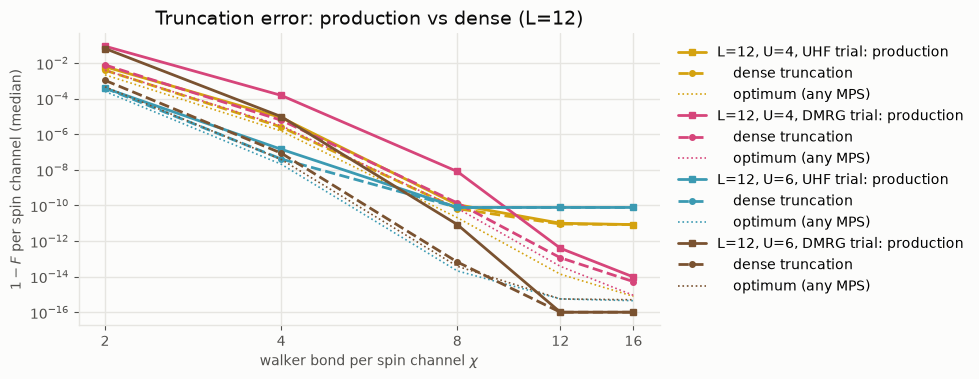

saved dense_truncation_data/accuracy_overlap.png


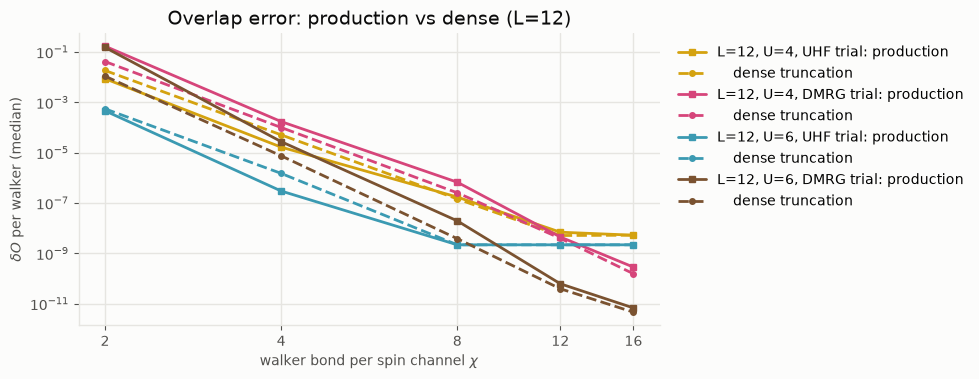

In [7]:
q = lambda x: f"{np.median(x):8.1e} ({np.percentile(x, 99):7.1e})"
print(f"{'set':12s} {'chi':>3s}   {'1-F production':>18s}   {'1-F dense':>18s}   {'optimum':>18s}   "
      f"{'dO production':>18s}   {'dO dense':>18s}   {'1-F ratio':>9s}  {'dO ratio':>8s}")
for name in SETS:
    for k, chi in enumerate(CHIS):
        if chi > 8:
            continue
        r = R[name][chi]
        p_, d_, a_ = 1 - r["F_prod"], 1 - r["F_dense"], R[name]["a"][..., k]
        print(f"{name:12s} {chi:3d}   {q(p_)}   {q(d_)}   {q(a_)}   {q(r['dO_prod'])}   {q(r['dO_dense'])}   "
              f"{np.median(p_) / np.median(d_):9.1f}  {np.median(r['dO_prod']) / np.median(r['dO_dense']):8.1f}")
    print()

x = np.array(CHIS)
FLOOR = 1e-16
for metric, ylabel, title, fname in (("F", r"$1-F$ per spin channel (median)", "Truncation error: production vs dense", "accuracy_infidelity"),
                                     ("dO", r"$\delta O$ per walker (median)", "Overlap error: production vs dense", "accuracy_overlap")):
    fig, ax = plt.subplots(figsize=(7.5, 3.8))
    for name in [n for n in SETS if SETS[n]["L"] == 12]:
        get = (lambda r, key: 1 - r[f"F_{key}"]) if metric == "F" else (lambda r, key: r[f"dO_{key}"])
        ax.plot(x, [np.median(np.maximum(get(R[name][c], "prod"), FLOOR)) for c in CHIS], "-", marker="s", ms=4,
                color=COLOR[name], label=f"{LABEL[name]}: production")
        ax.plot(x, [np.median(np.maximum(get(R[name][c], "dense"), FLOOR)) for c in CHIS], "--", marker="o", ms=4,
                color=COLOR[name], label="    dense truncation")
        if metric == "F":
            ax.plot(x, [np.median(np.maximum(R[name]["a"][..., k], FLOOR)) for k in range(len(CHIS))], ":", lw=1.2,
                    color=COLOR[name], label="    optimum (any MPS)")
    ax.set_xscale("log", base=2); ax.set_yscale("log"); ax.set_xticks(x, [str(c) for c in CHIS])
    ax.set_xlabel(r"walker bond per spin channel $\chi$"); ax.set_ylabel(ylabel)
    ax.set_title(title + " (L=12)")
    ax.legend(**LEGEND)
    save(fig, fname); plt.show()

## D5: cost

Wall time of one jitted, vmapped call that takes raw walkers (both spins) to their overlap with the DMRG trial, for:

- **production**: `make_walker_ops(...).overlap`, which does QR, charge-blocked conversion with frozen counts, and the blocked overlap contraction;
- **dense truncation**: QR, `channel_mps_dense` for both spins, and `dmrg_overlap_parity`.

It's timed at $L=12$ (the $U=4$ DMRG set, 200 walkers) and at $L=32$ (`fixed_block_walkers.ipynb`'s DMRG trial and 200 of its UHF-run walkers; the conversion cost doesn't depend on which walkers). Each configuration is timed twice, in alternating order. "First" is the first call, compilation included. "Call" is the better of the two medians over `TIMING_REPS` calls. Timings in one process on a laptop CPU are only indicative. The fast sweep is not included.

In [8]:
def time_call(f, *args):
    start = time.perf_counter()
    jax.block_until_ready(f(*args))
    first = time.perf_counter() - start                   # compilation plus one call
    runs = []
    for _ in range(TIMING_REPS):
        start = time.perf_counter()
        jax.block_until_ready(f(*args))
        runs.append(time.perf_counter() - start)
    return first, float(np.median(runs))


def make_dense_overlap(plans, chi, trial):
    def one(wa, wb):
        (qa, ra), (qb, rb) = jnp.linalg.qr(wa), jnp.linalg.qr(wb)
        (A, ga), (B, gb) = channel_mps_dense(qa, plans[0], chi), channel_mps_dense(qb, plans[1], chi)
        return jnp.linalg.det(ra) * jnp.linalg.det(rb) * ga * gb * dmrg_overlap_parity(A, B, trial)
    return jax.jit(jax.vmap(one))


def timing_case(T_np, q_T, refs, walkers, chis):
    # per chi: (first call, median call) for production and dense, each timed twice in alternating order
    plans = [make_orbital_plan(C, "adaptive", EPS) for C in refs]
    args = tuple(jnp.asarray(w) for w in walkers)
    out = {}
    for chi in chis:
        bonds = [plan_bonds(C, p, chi, 0.0) for C, p in zip(refs, plans)]
        ops = mcn.make_walker_ops(*refs, *plans, *bonds, T_np, q_T)
        f = dict(prod=jax.jit(jax.vmap(lambda a, b: ops.overlap((a, b)))),
                 dense=make_dense_overlap(plans, chi, [jnp.asarray(A) for A in T_np]))
        t = {key: [] for key in f}
        for key in ("prod", "dense", "prod", "dense"):
            t[key].append(time_call(f[key], *args))
        out[chi] = {key: (t[key][0][0], min(x[1] for x in t[key])) for key in t}
    return out


def build_cost():
    name = "L12_U4_dmrg"
    z12 = np.load(DATA_DIR / f"dmrg_trial_L12_U4_chi{TRIAL_CHI}_tensors.npz")
    c12 = timing_case([z12[f"T{i}"] for i in range(12)], tuple(z12[f"q{i}"] for i in range(13)), REF[name],
                      (WALK[name][0][:200], WALK[name][1][:200]), TIMING_CHIS[12])
    z = np.load(L32_TRIAL)
    T32 = [z[f"T{i}"] for i in range(32)]
    NO32 = tuple(mcn.natural_orbitals(g, 16)[0] for g in mcn.one_rdm(T32))
    w32 = np.load(L32_WALKERS)
    c32 = timing_case(T32, tuple(z[f"q{i}"] for i in range(33)), NO32, (w32["up"][-1], w32["dn"][-1]), TIMING_CHIS[32])
    out = {}
    for L_, c in ((12, c12), (32, c32)):
        for key in ("prod", "dense"):
            out[f"L{L_}_{key}"] = np.array([[chi, *c[chi][key]] for chi in c])      # rows: chi, first call s, call s
    return out


COST = cached(DATA_DIR / f"cost_reps{TIMING_REPS}.npz", build_cost)
print(f"{'L':>3s} {'chi':>4s}   {'production: first, call':>24s}   {'dense: first, call':>21s}   {'dense/production':>16s}")
for L_ in (12, 32):
    for (chi, pf, pc), (_, df, dc) in zip(COST[f"L{L_}_prod"], COST[f"L{L_}_dense"]):
        print(f"{L_:3d} {int(chi):4d}   {pf:8.1f} s {1e3 * pc:9.1f} ms   {df:7.1f} s {1e3 * dc:8.1f} ms   {dc / pc:16.2f}")

computed cost_reps20.npz in 284 s
  L  chi    production: first, call      dense: first, call   dense/production
 12    2        2.3 s      13.2 ms       1.4 s     29.0 ms               2.20
 12    4        2.6 s      31.5 ms       1.5 s     51.5 ms               1.63
 12    8        3.2 s      43.9 ms       1.6 s     81.3 ms               1.85
 12   12        3.2 s      53.4 ms       1.8 s    103.5 ms               1.94
 12   16        3.4 s      64.9 ms       1.7 s    131.3 ms               2.02
 32    4       13.7 s     140.3 ms       7.9 s    224.8 ms               1.60
 32    8       17.3 s     218.8 ms       8.4 s    390.2 ms               1.78
 32   12       18.3 s     254.9 ms       8.4 s    546.4 ms               2.14
 32   16       18.0 s     386.4 ms       8.5 s    743.5 ms               1.92


## D6: accuracy at equal cost

Dense truncation costs more per call than production at the same $\chi$. The fair comparison is therefore accuracy against the time per call, with production allowed a larger $\chi$. Below, for each $L=12$ set, the median error of each method is plotted against its $L=12$ time per call (200 walkers, D5), one marker per $\chi$. A method is better where its line lies lower at the same time.

saved dense_truncation_data/pareto_infidelity.png


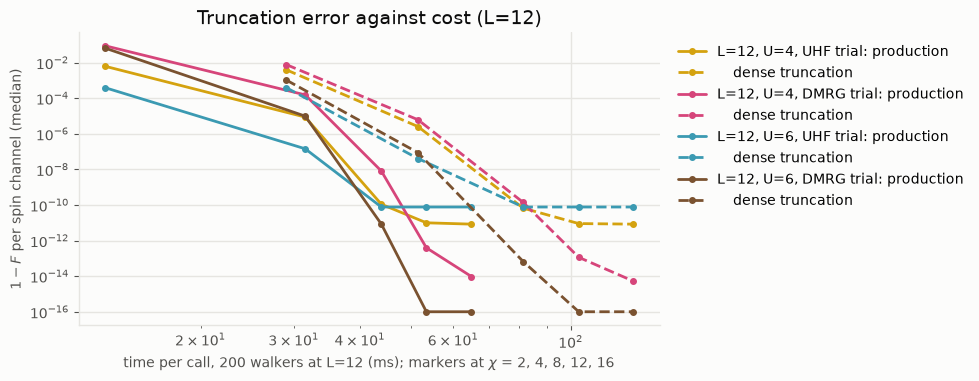

saved dense_truncation_data/pareto_overlap.png


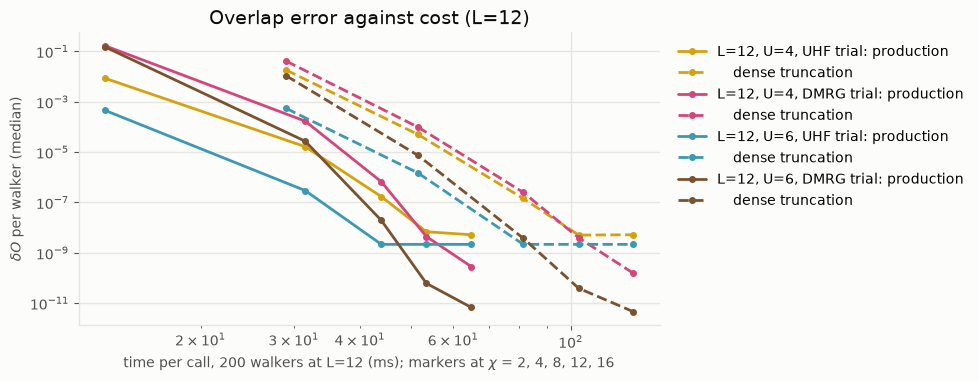

In [9]:
cost = {key: dict(zip(COST[f"L12_{key}"][:, 0].astype(int), 1e3 * COST[f"L12_{key}"][:, 2])) for key in ("prod", "dense")}
for metric, ylabel, title, fname in (("F", r"$1-F$ per spin channel (median)", "Truncation error against cost (L=12)", "pareto_infidelity"),
                                     ("dO", r"$\delta O$ per walker (median)", "Overlap error against cost (L=12)", "pareto_overlap")):
    fig, ax = plt.subplots(figsize=(7.5, 3.8))
    for name in [n for n in SETS if SETS[n]["L"] == 12]:
        for key, ls, lab in (("prod", "-", "production"), ("dense", "--", "dense truncation")):
            y = [np.median(np.maximum(1 - R[name][c][f"F_{key}"] if metric == "F" else R[name][c][f"dO_{key}"], FLOOR)) for c in CHIS]
            ax.plot([cost[key][c] for c in CHIS], y, ls, marker="o", ms=4, color=COLOR[name],
                    label=f"{LABEL[name]}: {lab}" if key == "prod" else f"    {lab}")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(r"time per call, 200 walkers at L=12 (ms); markers at $\chi$ = " + ", ".join(map(str, CHIS)))
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(**LEGEND)
    save(fig, fname); plt.show()

## Summary

$L=8$ and $12$, $U=4$ and $6$, UHF and DMRG ($\chi_T=8$) trials; 300 walkers per set (6 sampling snapshots of `entanglement_vs_gmps.ipynb`'s runs), every error exact against the dense walker.

**Dense truncation is the walker's own counts, with static shapes.**

- It gives the same states as `channel_mps_own` to $10^{-15}$ in fidelity, with the same kept norm to $2\times10^{-14}$, in every set and at every $\chi$.
- No weight leaks out of the walker's particle number (at most $7\times10^{-16}$), so the dense split never mixed charge sectors here.
- The parity-carrying DMRG overlap equals the charge-labelled one to $10^{-15}$.
- Against production's own functions run with the walker's counts (`plan_bonds(Q, ...)`), the difference is at most $10^{-8}$ in $1-F$. It appears only where that NumPy dry run broke a near-tie between sectors the other way; both are valid own counts.
- A dense SVD gives the same states as the Gram eigh used here, 1.7× slower.

**Accuracy at the same $\chi$:** within 1–2× of the optimum, as expected for own counts.

- DMRG trial: 11–127× lower infidelity than production, and 1.0–17× lower $\delta O$.
- UHF trial: 1.0–4.2× lower infidelity, but *not* a better overlap. At $\chi\le4$ its $\delta O$ is 0.2–0.8× production's, i.e. worse. Production's counts are frozen on the UHF trial itself, so they keep the part of the walker that overlaps the trial; `fixed_block_walkers.ipynb` saw the same at $L=32$.

**Cost at the same $\chi$:** 1.6–2.2× production per call, at $L=12$ and $32$ alike. It compiles about twice as fast.

- The extra time is in the conversion: an eigh of the whole $2D\times2D$ two-site Gram matrix at every gate, against production's smaller per-sector blocks.
- The parity-carrying overlap costs about the same as production's blocked one: 15–34 ms against 20–30 ms at $L=32$.

**At equal cost, production wins everywhere.** Spending the same time on a larger production $\chi$ gives a smaller error than dense truncation, at every cost level in all four $L=12$ sets, for both $1-F$ and $\delta O$. For example, at $L=12$, $U=4$ with the DMRG trial:

| method | $\chi$ | time per call | $1-F$ | $\delta O$ |
|---|---|---|---|---|
| dense truncation | 4 | 52 ms | $6.1\times10^{-6}$ | $9.9\times10^{-5}$ |
| production | 8 | 44 ms | $8.1\times10^{-9}$ | $6.6\times10^{-7}$ |

So per-walker counts through a dense split don't pay as a replacement for production's conversion; raising $\chi_w$ does more for the same time.

**Caveats.**

- The fast sweep, most of production's time per step, is not ported. A dense version would carry the parity index through its environments too, and its cost ratio is unmeasured.
- Timings come from one process on a laptop CPU.
- Accuracy is measured only at $L\le12$. The $L=32$ numbers of `fixed_block_walkers.ipynb` (own counts 7.5–18× better than production for the DMRG trial) suggest the same picture, but equal-cost accuracy wasn't measured there.